#### Classificação de imagens usando o scikit-learn

O `scikit-learn` é uma biblioteca de código aberto para Machine Learning em Python. Ele fornece um conjunto abrangente de ferramentas para aprendizado supervisionado e não supervisionado, incluindo algoritmos de classificação, regressão, clusterização e redução de dimensionalidade. Além disso, a biblioteca oferece funcionalidades para pré-processamento de dados, seleção de modelos, avaliação de desempenho e pipelines.

A documentação do scikit-learn pode ser encontrada em: https://scikit-learn.org/stable/user_guide.html

As vantagens do uso dessa biblioteca são:

- Ampla variedade de algoritmos de classificação, regressão e clusterização;
- Integração com outras bibliotecas como NumPy, SciPy, pandas, Matplotlib...
- API bem documentada;
- Suporte a pipelines;
- Boa eficiencia computacional.

Instalação pelo conda:

`$ conda install -c conda-forge scikit-learn`

##### Exemplo de classificação usando scikit-learn

In [2]:
import numpy as np
import rasterio as rio
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap


In [3]:
# Importação da imagem e das amostras em formato raster

image_path = "C:/Users/PC/Desktop/dados_artigo_geoinfo/REC_2010_ALPSRP234707120_Cal_ML_Spk3_DSk_TC_modificado_aligned.TIF"
samples_path = "C:/Users/PC/Desktop/dados_artigo_geoinfo/df_samples_5classes.csv"

In [ ]:
# Abrindo e lendo imagem utilizando o rasterio
with rio.open(image_path) as src:
    image = src.read() 
    meta = src.meta

In [6]:
meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': None,
 'width': 916,
 'height': 1996,
 'count': 2,
 'crs': CRS.from_wkt('PROJCS["SIRGAS 2000 / UTM zone 21S",GEOGCS["SIRGAS 2000",DATUM["Sistema_de_Referencia_Geocentrico_para_las_AmericaS_2000",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6674"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4674"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","31981"]]'),
 'transform': Affine(14.999999999788049, 0.0, 726134.9999992558,
        0.0, -14.999999999788049, 9668515.000008777)}

In [28]:
# Lendo amostras em CSV com a função pd.read_csv
df_samples = pd.read_csv(samples_path)
df_samples

,Unnamed: 0,Class,HH,HV
0,1,AC+AP,0.029698,0.002887
1,2,AC+AP,0.040384,0.001440
2,3,AC+AP,0.000927,0.001057
3,4,AC+AP,0.009453,0.020962
4,5,AC+AP,0.007441,0.007155
...,...,...,...,...
70950,70951,VS1+VS2+VS3,0.032709,0.000050
70951,70952,VS1+VS2+VS3,0.040608,0.026978
70952,70953,VS1+VS2+VS3,0.102743,0.007115
70953,70954,VS1+VS2+VS3,0.005984,0.085068


In [ ]:
del df_samples[df_samples.columns[0]]

In [30]:
df_samples

,Class,HH,HV
0,AC+AP,0.029698,0.002887
1,AC+AP,0.040384,0.001440
2,AC+AP,0.000927,0.001057
3,AC+AP,0.009453,0.020962
4,AC+AP,0.007441,0.007155
...,...,...,...
70950,VS1+VS2+VS3,0.032709,0.000050
70951,VS1+VS2+VS3,0.040608,0.026978
70952,VS1+VS2+VS3,0.102743,0.007115
70953,VS1+VS2+VS3,0.005984,0.085068


In [31]:
n_classes = df_samples['Class'].nunique() # Quantidade de objetos únicos
n_classes

5

In [32]:
# Observando os tipos de dados presentes no dataframe
df_samples.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70955 entries, 0 to 70954
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Class   70955 non-null  object 
 1   HH      70955 non-null  float64
 2   HV      70955 non-null  float64
dtypes: float64(2), object(1)
memory usage: 1.6+ MB


In [33]:
# Mudando o tipo do dado para category
df_samples['Class'] = df_samples['Class'].astype('category')
df_samples.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70955 entries, 0 to 70954
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   Class   70955 non-null  category
 1   HH      70955 non-null  float64 
 2   HV      70955 non-null  float64 
dtypes: category(1), float64(2)
memory usage: 1.2 MB


In [34]:
df_samples.describe()

,HH,HV
count,7.095500e+04,7.095500e+04
mean,5.457418e-02,1.533186e-02
std,7.352982e-02,1.954343e-02
min,3.623238e-07,1.288540e-07
25%,1.156655e-02,2.422935e-03
50%,3.154679e-02,8.165442e-03
75%,7.250060e-02,2.077834e-02
max,3.486452e+00,3.457898e-01


In [35]:
# Acessando o shape da imagem
img_bands, img_rows, img_cols = image.shape
image.shape

(2, 1996, 916)

In [36]:
# Nomeando as bandas 
band_names = ["HH","HV"]

In [37]:
# imagem como um objeto 2d
aux = image.reshape(img_bands,img_rows*img_cols).T
aux

array([[0.06791805, 0.05188816],
       [0.0664543 , 0.01246473],
       [0.06217724, 0.01941418],
       ...,
       [0.05948117, 0.01658882],
       [0.0653841 , 0.01988442],
       [0.05756436, 0.01622571]], shape=(1828336, 2), dtype=float32)

In [38]:
# imagem como um objeto 2d [ I ]
I = pd.DataFrame(aux)
I.columns = band_names
I

,HH,HV
0,0.067918,0.051888
1,0.066454,0.012465
2,0.062177,0.019414
3,0.062177,0.019414
4,0.029987,0.026326
...,...,...
1828331,0.066311,0.013071
1828332,0.104893,0.013411
1828333,0.059481,0.016589
1828334,0.065384,0.019884


Preparação para classificação de imagens

In [26]:
X = df_samples.copy()# DADOS SEM O LABEL 
X

,Class,HH,HV
0,AC+AP,0.029698,0.002887
1,AC+AP,0.040384,0.001440
2,AC+AP,0.000927,0.001057
3,AC+AP,0.009453,0.020962
4,AC+AP,0.007441,0.007155
...,...,...,...
70950,VS1+VS2+VS3,0.032709,0.000050
70951,VS1+VS2+VS3,0.040608,0.026978
70952,VS1+VS2+VS3,0.102743,0.007115
70953,VS1+VS2+VS3,0.005984,0.085068


In [ ]:
y = X['Class'] # LABELS
X = X.drop(columns=['Class']) # tirando os rótulos

print(X)
print(y)



In [41]:
classes = y.unique()
print(classes)


['AC+AP', 'FP+FD', 'PL+PS', 'SE', 'VS1+VS2+VS3']
Categories (5, object): ['AC+AP', 'FP+FD', 'PL+PS', 'SE', 'VS1+VS2+VS3']


In [46]:
# transformando os rótulos em índices

# criando um codificador
encoder = LabelEncoder()
encoder.fit(y)
encoder.classes_

array(['AC+AP', 'FP+FD', 'PL+PS', 'SE', 'VS1+VS2+VS3'], dtype=object)

In [47]:
# Dividindo X em conjunto de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3, random_state=40)

In [ ]:
# Observando o dado criado...
print(X_train)
print(y_train)

In [49]:
# CLASSIFICAÇÃO
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

# Criando um objeto para o modelo RF
rf = RandomForestClassifier(n_estimators = 200, random_state = 42)

# Gerando o modelo nos dados de treino
rf.fit(X_train, y_train)
     

RandomForestClassifier(n_estimators=200, random_state=42)

In [50]:
# Realizando predição
y_pred = rf.predict(X_test)
y_pred

array(['FP+FD', 'VS1+VS2+VS3', 'AC+AP', ..., 'FP+FD', 'AC+AP', 'FP+FD'],
      shape=(21287,), dtype=object)

In [1]:
# Métricas 

# Acurácia Global
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia Global: {accuracy:.4f}')

# Matriz de Confusão
conf_matrix = confusion_matrix(y_test, y_pred, labels = classes)
conf_matri_df = pd.DataFrame(conf_matrix, index=classes, columns=classes)
print('Matriz de Confusão:\n', conf_matri_df)

# Cálculo das Acurácias do Produtor e Usuário 
# Lembre-se que a construção da matriz de confusão do scikit tem as dimensões trocadas:
# A verdade (referência) está na linha e a predição (classificação) nas colunas , então o cálculo fica invertido
producer_accuracy = conf_matrix.diagonal() / conf_matrix.sum(axis=1)  # Recall 
user_accuracy = conf_matrix.diagonal() / conf_matrix.sum(axis=0)  # Precision

print(f'Acurácia do Produtor por classe: {producer_accuracy}')
print(f'Acurácia do Usuário por classe: {user_accuracy}')


NameError: name 'accuracy_score' is not defined

In [52]:
# Relatório de métricas detalhado por classe sem precisar codar
print("\nRelatório de Classificação:")

print(classification_report(y_test, y_pred, target_names=classes))


Relatório de Classificação:
              precision    recall  f1-score   support

       AC+AP       0.41      0.35      0.38      2230
       FP+FD       0.69      0.84      0.76     11617
       PL+PS       0.40      0.29      0.34      2915
          SE       0.46      0.47      0.47      1403
 VS1+VS2+VS3       0.46      0.22      0.29      3122

    accuracy                           0.60     21287
   macro avg       0.48      0.44      0.45     21287
weighted avg       0.57      0.60      0.57     21287



In [53]:
# Rodando predição em toda imagem
pred_rf = rf.predict(I)

In [54]:
pred_rf

array(['FP+FD', 'PL+PS', 'FP+FD', ..., 'FP+FD', 'FP+FD', 'FP+FD'],
      shape=(1828336,), dtype=object)

In [55]:
# Reajustando os rótulos com os índices das classes
pred_rf = encoder.transform(pred_rf)
pred_rf

array([1, 2, 1, ..., 1, 1, 1], shape=(1828336,))

In [56]:
# Retornando para o formato original
pred_rf_final = pred_rf.reshape(img_rows,img_cols)

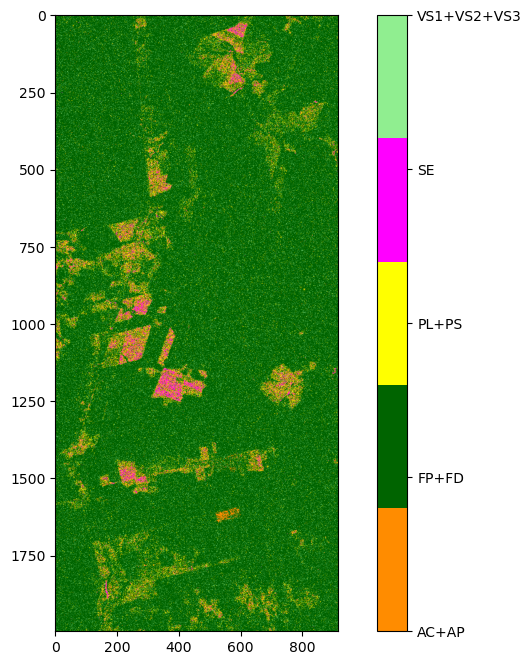

In [57]:
# Visualizando
# https://matplotlib.org/stable/gallery/color/named_colors.html
cmap = ListedColormap(['darkorange','darkgreen','yellow','magenta','lightgreen'])

plt.figure(figsize=(10, 8)) 
plt.imshow(pred_rf_final, cmap=cmap)

# Criar a barra de cores
cbar = plt.colorbar()
cbar.set_ticks(np.arange(0, 5))
cbar.set_ticklabels(['AC+AP', 'FP+FD', 'PL+PS', 'SE', 'VS1+VS2+VS3'])
plt.show()

In [58]:
# Exportando imagem com Rasterio
output_path = "C:/Users/PC/Desktop/imagem_classificada.TIF"

In [59]:
meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': None,
 'width': 916,
 'height': 1996,
 'count': 2,
 'crs': CRS.from_wkt('PROJCS["SIRGAS 2000 / UTM zone 21S",GEOGCS["SIRGAS 2000",DATUM["Sistema_de_Referencia_Geocentrico_para_las_AmericaS_2000",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6674"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4674"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","31981"]]'),
 'transform': Affine(14.999999999788049, 0.0, 726134.9999992558,
        0.0, -14.999999999788049, 9668515.000008777)}

In [60]:
meta_out = meta.copy() # copiando os metadados da imagem original
meta_out.update({
    "dtype": "uint8",   # Tipo de dado da imagem classificada
    "count": 1          # Apenas uma banda na saída
})

In [ ]:
# Exportando imagem com Rasterio
with rio.open(output_path, 'w', **meta_out) as dst:
    dst.write(pred_rf_final,1)

print(f"Imagem classificada salva em: {output_path}")

Imagem classificada salva em: C:/Users/PC/Desktop/imagem_classificada.TIF


#### Calculando imagem entropia



In [63]:
# Calculando as imagens de probabilidade a partir do array 2d
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier.predict_proba
image_probs = rf.predict_proba(I) # I imagem 2d como dataframe

In [65]:
image_probs

array([[0.   , 0.78 , 0.035, 0.   , 0.185],
       [0.   , 0.15 , 0.465, 0.   , 0.385],
       [0.   , 0.9  , 0.015, 0.   , 0.085],
       ...,
       [0.   , 0.825, 0.15 , 0.   , 0.025],
       [0.   , 0.63 , 0.01 , 0.   , 0.36 ],
       [0.   , 0.385, 0.265, 0.   , 0.35 ]], shape=(1828336, 5))

In [64]:
# voltando ao shape correto
pred_rf_proba = image_probs.T.reshape(n_classes,img_rows,img_cols)

In [74]:
pred_rf_proba.shape

(5, 1996, 916)

In [ ]:
# Função para calcular a entropia para cada pixel
def entropy(probability):
    epsilon = 1e-10  
    result = -np.sum(probability * np.log(probability+epsilon), axis=0)
    return result

In [71]:
entropia = entropy(pred_rf_proba)

In [72]:
# Função para plot da entropia
def plot_entropia(entropia):
    plt.figure(figsize=(8, 6))
    plt.imshow(entropia, cmap="coolwarm", interpolation="nearest")
    plt.colorbar(label="Entropia")
    plt.title("Mapa de Entropia")
    plt.xlabel("Colunas")
    plt.ylabel("Linhas")
    plt.show()

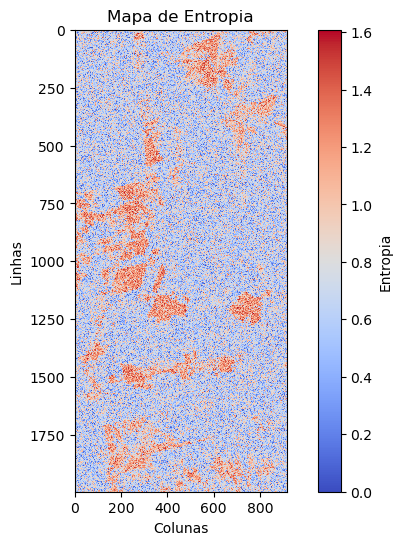

In [73]:
plot_entropia(entropia)